In [1]:
import os
from pathlib import Path
import argparse
from collections import defaultdict
import pandas as pd
import json
from tqdm import tqdm  # For progress bar
from PIL import Image, ImageOps
import numpy as np
import torch
from tqdm import tqdm

from typing import Union
from facenet_pytorch import InceptionResnetV1, MTCNN, fixed_image_standardization
 # InceptionResnetV1 as a facenet backbone
from PIL import Image
from torchvision import transforms
from facenet_pytorch.models import mtcnn as mtcnn_mod
import torch.nn.functional as F

In [2]:
def _extract_face_float(img, box, image_size=160, margin=0, save_path=None):
    """
    Replacement for facenet_pytorch.models.utils.detect_face.extract_face
    Accepts float32 arrays/tensors without quantizing to uint8.
    - img: np.ndarray HWC float32 in [0,255], or torch.Tensor CHW/HWC float32 in [0,255]
    - box: [x1, y1, x2, y2]
    Returns: torch.Tensor [3, image_size, image_size] float32 in [0,255]
    """
    # to numpy HWC float32
    if isinstance(img, torch.Tensor):
        if img.dim() == 3 and img.shape[0] in (1, 3):      # CHW
            img = img.permute(1, 2, 0).cpu().numpy()
        elif img.dim() == 3 and img.shape[2] in (1, 3):    # HWC
            img = img.cpu().numpy()
        else:
            raise ValueError(f"Unsupported tensor shape: {tuple(img.shape)}")
    elif isinstance(img, np.ndarray):
        pass  # already fine
    else:
        # likely PIL.Image – fallback (esto cuantiza, evítalo en la ruta npy)
        img = np.asarray(img, dtype=np.float32)

    img = img.astype(np.float32)
    h, w = img.shape[:2]

    x1, y1, x2, y2 = [float(b) for b in box]
    if isinstance(margin, int):
        mx = my = margin
    else:
        mx, my = margin

    x1 = max(0.0, x1 - mx / 2.0)
    y1 = max(0.0, y1 - my / 2.0)
    x2 = min(w,   x2 + mx / 2.0)
    y2 = min(h,   y2 + my / 2.0)

    x1i, y1i, x2i, y2i = int(round(x1)), int(round(y1)), int(round(x2)), int(round(y2))
    face_np = img[y1i:y2i, x1i:x2i, :]  # H',W',C

    if face_np.size == 0:
        face_np = np.zeros((image_size, image_size, 3), dtype=np.float32)
        face_t = torch.from_numpy(face_np).permute(2, 0, 1)  # C,H,W
    else:
        face_t = torch.from_numpy(face_np).permute(2, 0, 1).unsqueeze(0).float()  # 1,C,H,W
        face_t = F.interpolate(face_t, size=(image_size, image_size),
                               mode='bilinear', align_corners=False)
        face_t = face_t.squeeze(0)  # C,H,W

    return face_t

In [3]:
def _PIL_numpy_to_tensor(img_any, to_CHW: bool = False) -> torch.Tensor:
    """
    Convert input image to float32 tensor WHC in [0,255] WITHOUT quantizing.
    - If PIL: converts to numpy float (already 8-bit source, but we don't re-quantize)
    - If numpy HWC: just wraps
    """
    if isinstance(img_any, Image.Image):
        # PNG path: source is 8-bit, but we keep it float afterwards
        arr = np.array(img_any.convert('RGB'), dtype=np.float32)  # H,W,3 in [0,255]
        if to_CHW:
            arr = np.transpose(arr, (2, 0, 1))  # C,H,W
        ten = torch.from_numpy(arr).float()      # H,W,3
        return ten

    if isinstance(img_any, np.ndarray):
        arr = img_any
        arr = arr.astype(np.float32)   
        if to_CHW:
            arr = np.transpose(arr, (2, 0, 1)) # keep decimals
        ten = torch.from_numpy(arr).float()       # H,W,3
        return ten

    raise TypeError(f"Unsupported type: {type(img_any)}")

def preprocess_for_facenet(img_any, to_CHW: bool = False) -> torch.Tensor:
    """
    Returns a tensor [1,3,S,S] ready for FaceNet:
    - Float32 in [0,1] after fixed_image_standardization
    """
    # 1) To CHW float [0,255]
    chw = _PIL_numpy_to_tensor(img_any, to_CHW=to_CHW)  # [1,3,H,W], float32
    #chw = chw.unsqueeze(0)  # [1,3,H,W]
    # 2) standardize (FaceNet expects fixed_image_standardization)   
    chw_std = fixed_image_standardization(chw)  # [3,S,S], float32
        
    return chw_std  # ready for FaceNet

In [4]:
def get_distance(emb1: torch.Tensor, emb2: torch.Tensor, metric: str) -> float:
    """
    Calculate the distance between two facial embeddings.

    Args:
        emb1: First embedding tensor.
        emb2: Second embedding tensor.
        metric: Distance metric to use ('euclidean' or 'cosine').

    Returns:
        Distance as a float.
    """
    if emb1.shape != emb2.shape:
        raise ValueError("Embeddings must have the same shape.")

    # Calculate the distance
    if metric == 'cosine':
        # Cosine distance
        emb1_norm = emb1 / emb1.norm(p=2, dim=0, keepdim=True)
        emb2_norm = emb2 / emb2.norm(p=2, dim=0, keepdim=True)
        #cosine_similarity = F.cosine_similarity(emb1.unsqueeze(0), emb2.unsqueeze(0), dim=0)
        cosine_similarity = torch.dot(emb1_norm, emb2_norm).item()
        distance = 1 - cosine_similarity
    elif metric == 'euclidean':
        # Euclidean distance
        distance = torch.norm(emb1 - emb2).item()
    else:
        raise ValueError("Unsupported metric. Use 'euclidean' or 'cosine'.")

    return distance

def load_and_preprocess_image(image_path, img_size, img_norm=False, image_format='png'):
    # Apply some operations before getting the embedding if needed, depend on the watermarking model
    if image_format == 'png':
        img = Image.open(image_path).convert('RGB')
        img_cover = ImageOps.fit(img, (img_size, img_size))

    elif image_format == 'npy':
        img_cover = np.load(image_path, allow_pickle=True).astype(np.float32)

    return img_cover

In [6]:
dataset = 'CFD'
watermarking_model = 'stegformer'
experiment_name = '1_1_clamp_StegFormer-B_baseline'
train_dataset = 'coco'
image_name = 'BM239_136_N.jpg' # BF001_025_N BF002_001_N BF005_001_N BF200_080_N BF202_109_N BM012_018_N BM230_232_N
template_name = 'BF001.jpg'
img_size = 256
image_format = 'npy'
device = 'cpu'

In [7]:

test_path = Path(f'/app/facial_data/{dataset}/processed/test/{image_name}')
templates_path = Path(f'/app/facial_data/{dataset}/processed/templates/{template_name}')
watermarked_path = Path(f'/app/output/watermarking/{watermarking_model}/{experiment_name}/inference/{train_dataset}/{dataset}/watermarked_images/{image_name.replace("jpg",image_format)}')
watermarked_templates = Path(f'/app/output/watermarking/{watermarking_model}/{experiment_name}/inference/{train_dataset}/{dataset}/watermarked_templates/{template_name.replace("jpg",image_format)}')

In [8]:
# load the images
test_image = load_and_preprocess_image(test_path, img_size, img_norm=False, image_format='png')
template_image = load_and_preprocess_image(templates_path, img_size, img_norm=False, image_format='png')
template_wm_array = load_and_preprocess_image(watermarked_path, img_size, img_norm=False, image_format='npy')
test_wm_array = load_and_preprocess_image(watermarked_templates, img_size, img_norm=False, image_format='npy')

In [123]:
test_wm_array

array([[[0.9900079 , 0.9851438 , 0.99194175],
        [0.9963293 , 0.990777  , 0.98673564],
        [0.9954401 , 0.9976721 , 0.9909007 ],
        ...,
        [0.99707204, 0.990705  , 0.99258965],
        [0.99055165, 0.9933137 , 0.9931604 ],
        [0.9778689 , 0.9829307 , 0.9734048 ]],

       [[0.99580604, 0.9986866 , 0.98646146],
        [0.9996344 , 0.99209744, 1.        ],
        [1.        , 0.9952127 , 0.99872667],
        ...,
        [0.99082285, 0.9980763 , 0.9932504 ],
        [0.9969244 , 0.992559  , 0.9859851 ],
        [0.9925419 , 0.989392  , 0.98544437]],

       [[0.99588627, 0.9984447 , 0.99272484],
        [0.99966836, 0.9954833 , 0.99054235],
        [0.9977819 , 0.9995857 , 0.9974368 ],
        ...,
        [0.9984009 , 0.99316347, 0.9904265 ],
        [0.9948602 , 0.9980837 , 0.9913569 ],
        [0.98723155, 0.9958417 , 1.        ]],

       ...,

       [[0.770138  , 0.7782591 , 0.75898117],
        [0.7729457 , 0.78708607, 0.75946087],
        [0.7819733 , 0

In [124]:
test_wm_array[:,:,0]

array([[0.9900079 , 0.9963293 , 0.9954401 , ..., 0.99707204, 0.99055165,
        0.9778689 ],
       [0.99580604, 0.9996344 , 1.        , ..., 0.99082285, 0.9969244 ,
        0.9925419 ],
       [0.99588627, 0.99966836, 0.9977819 , ..., 0.9984009 , 0.9948602 ,
        0.98723155],
       ...,
       [0.770138  , 0.7729457 , 0.7819733 , ..., 0.8433948 , 0.8419272 ,
        0.85502446],
       [0.7861202 , 0.79464775, 0.7942114 , ..., 0.83559746, 0.8375505 ,
        0.8403714 ],
       [0.7660081 , 0.7637203 , 0.7636523 , ..., 0.8245584 , 0.8126659 ,
        0.8004729 ]], dtype=float32)

In [125]:
test_wm_array[:,:,1]

array([[0.9851438 , 0.990777  , 0.9976721 , ..., 0.990705  , 0.9933137 ,
        0.9829307 ],
       [0.9986866 , 0.99209744, 0.9952127 , ..., 0.9980763 , 0.992559  ,
        0.989392  ],
       [0.9984447 , 0.9954833 , 0.9995857 , ..., 0.99316347, 0.9980837 ,
        0.9958417 ],
       ...,
       [0.7782591 , 0.78708607, 0.7886244 , ..., 0.8480316 , 0.8379491 ,
        0.85370743],
       [0.7963316 , 0.80235654, 0.8033387 , ..., 0.84037286, 0.8380221 ,
        0.85041386],
       [0.77216893, 0.77768546, 0.77608156, ..., 0.81919503, 0.80709255,
        0.79271823]], dtype=float32)

In [126]:
test_wm_array[:,:,2]

array([[0.99194175, 0.98673564, 0.9909007 , ..., 0.99258965, 0.9931604 ,
        0.9734048 ],
       [0.98646146, 1.        , 0.99872667, ..., 0.9932504 , 0.9859851 ,
        0.98544437],
       [0.99272484, 0.99054235, 0.9974368 , ..., 0.9904265 , 0.9913569 ,
        1.        ],
       ...,
       [0.75898117, 0.75946087, 0.7709162 , ..., 0.8176165 , 0.81161577,
        0.8198147 ],
       [0.77107054, 0.7824443 , 0.78754175, ..., 0.80537784, 0.79920423,
        0.80723274],
       [0.7449206 , 0.7428256 , 0.7475132 , ..., 0.78435427, 0.77486956,
        0.76274794]], dtype=float32)

In [127]:
tensor = torch.from_numpy(test_wm_array).float()

In [128]:
tensor = tensor.permute(2, 0, 1)

In [129]:
tensor[0]

tensor([[0.9900, 0.9963, 0.9954,  ..., 0.9971, 0.9906, 0.9779],
        [0.9958, 0.9996, 1.0000,  ..., 0.9908, 0.9969, 0.9925],
        [0.9959, 0.9997, 0.9978,  ..., 0.9984, 0.9949, 0.9872],
        ...,
        [0.7701, 0.7729, 0.7820,  ..., 0.8434, 0.8419, 0.8550],
        [0.7861, 0.7946, 0.7942,  ..., 0.8356, 0.8376, 0.8404],
        [0.7660, 0.7637, 0.7637,  ..., 0.8246, 0.8127, 0.8005]])

In [130]:
tensor[1]

tensor([[0.9851, 0.9908, 0.9977,  ..., 0.9907, 0.9933, 0.9829],
        [0.9987, 0.9921, 0.9952,  ..., 0.9981, 0.9926, 0.9894],
        [0.9984, 0.9955, 0.9996,  ..., 0.9932, 0.9981, 0.9958],
        ...,
        [0.7783, 0.7871, 0.7886,  ..., 0.8480, 0.8379, 0.8537],
        [0.7963, 0.8024, 0.8033,  ..., 0.8404, 0.8380, 0.8504],
        [0.7722, 0.7777, 0.7761,  ..., 0.8192, 0.8071, 0.7927]])

In [131]:
tensor[2]

tensor([[0.9919, 0.9867, 0.9909,  ..., 0.9926, 0.9932, 0.9734],
        [0.9865, 1.0000, 0.9987,  ..., 0.9933, 0.9860, 0.9854],
        [0.9927, 0.9905, 0.9974,  ..., 0.9904, 0.9914, 1.0000],
        ...,
        [0.7590, 0.7595, 0.7709,  ..., 0.8176, 0.8116, 0.8198],
        [0.7711, 0.7824, 0.7875,  ..., 0.8054, 0.7992, 0.8072],
        [0.7449, 0.7428, 0.7475,  ..., 0.7844, 0.7749, 0.7627]])

In [133]:
tensor * 255 + 0.5

tensor([[[252.9520, 254.5640, 254.3372,  ..., 254.7534, 253.0907, 249.8566],
         [254.4305, 255.4068, 255.5000,  ..., 253.1598, 254.7157, 253.5982],
         [254.4510, 255.4154, 254.9344,  ..., 255.0922, 254.1893, 252.2440],
         ...,
         [196.8852, 197.6012, 199.9032,  ..., 215.5657, 215.1914, 218.5312],
         [200.9606, 203.1352, 203.0239,  ..., 213.5773, 214.0754, 214.7947],
         [195.8321, 195.2487, 195.2313,  ..., 210.7624, 207.7298, 204.6206]],

        [[251.7117, 253.1481, 254.9064,  ..., 253.1298, 253.7950, 251.1473],
         [255.1651, 253.4848, 254.2792,  ..., 255.0095, 253.6026, 252.7950],
         [255.1034, 254.3482, 255.3943,  ..., 253.7567, 255.0114, 254.4396],
         ...,
         [198.9561, 201.2070, 201.5992,  ..., 216.7480, 214.1770, 218.1954],
         [203.5646, 205.1009, 205.3514,  ..., 214.7951, 214.1956, 217.3555],
         [197.4031, 198.8098, 198.4008,  ..., 209.3947, 206.3086, 202.6431]],

        [[253.4451, 252.1176, 253.1797,  ...

In [10]:
from torchvision.utils import save_image
from PIL import Image
from torchvision import transforms
#from torchvision.transforms import InterpolationMode

transform = transforms.Compose([
        transforms.Resize((256,256), interpolation=Image.BICUBIC),  # PATCH
        transforms.ToTensor(),])

In [117]:
save_image(tensor,'test2.png')

In [118]:
im = Image.open("test2.png")
im = im.convert("RGB")

In [119]:
arr = np.array(img, dtype=float)
print(arr.shape)

(256, 256, 3)


In [120]:
arr[:,:,0]

array([[255., 255., 255., ..., 255., 255., 255.],
       [255., 255., 255., ..., 255., 255., 255.],
       [255., 255., 255., ..., 255., 255., 255.],
       ...,
       [255., 255., 255., ..., 255., 255., 255.],
       [255., 255., 255., ..., 255., 255., 255.],
       [255., 255., 255., ..., 255., 255., 255.]])

In [102]:
arr[:,:,1]

array([[255., 255., 255., ..., 255., 255., 255.],
       [255., 255., 255., ..., 255., 255., 255.],
       [255., 255., 255., ..., 255., 255., 255.],
       ...,
       [255., 255., 255., ..., 255., 255., 255.],
       [255., 255., 255., ..., 255., 255., 255.],
       [255., 255., 255., ..., 255., 255., 255.]])

In [103]:
arr[:,:,2]

array([[255., 255., 255., ..., 255., 255., 255.],
       [255., 255., 255., ..., 255., 255., 255.],
       [255., 255., 255., ..., 255., 255., 255.],
       ...,
       [255., 255., 255., ..., 255., 255., 255.],
       [255., 255., 255., ..., 255., 255., 255.],
       [255., 255., 255., ..., 255., 255., 255.]])

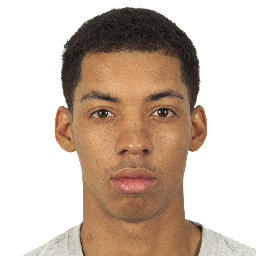

In [201]:
test_image

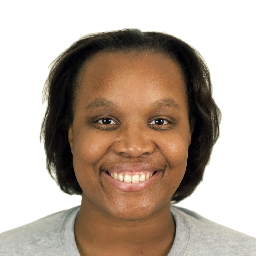

In [202]:
template_image

In [9]:
# all image comparison
model = InceptionResnetV1(pretrained='vggface2').eval().to(device=device)

In [204]:
#mtcnn = MTCNN(keep_all=False, post_process=False, device=device)
#mtcnn_mod.extract_face = _extract_face_float
#mtcnn = mtcnn_mod.MTCNN(keep_all=False, post_process=False, device=device)

In [205]:
#test_image_face = mtcnn(test_image) 
#template_image_face = mtcnn(template_image)
#template_wm_array_face = mtcnn(template_wm_array[None, ...])
#test_wm_array_face = mtcnn(test_wm_array[None, ...])

In [206]:
test_image_norm = preprocess_for_facenet(test_image, to_CHW = True)
template_image_norm = preprocess_for_facenet(template_image, to_CHW = True)
template_wm_array_norm = preprocess_for_facenet(template_wm_array, to_CHW = True)
test_wm_array_norm = preprocess_for_facenet(test_wm_array, to_CHW = True)

In [207]:
# get the embedding for the images oo and ww
emb_test_image_norm = model(test_image_norm.unsqueeze(0).to(device=device))
emb_template_image_norm = model(template_image_norm.unsqueeze(0).to(device=device))
emb_template_wm_array_norm = model(template_wm_array_norm.unsqueeze(0).to(device=device))
emb_test_wm_array_norm = model(test_wm_array_norm.unsqueeze(0).to(device=device))

In [208]:
oo_distance = get_distance(emb_template_image_norm.squeeze(0), emb_test_image_norm.squeeze(0), metric='cosine')
ww_distance = get_distance(emb_template_wm_array_norm.squeeze(0), emb_test_wm_array_norm.squeeze(0), metric='cosine')

In [209]:
oo_distance, ww_distance

(0.6208226382732391, 0.5976440608501434)

# Distribution exploration

In [12]:
from scipy import stats
import matplotlib.pyplot as plt

def plot_ks(genuinos, impostores, d_stat):
    # Ordenar los datos
    gen_sorted = np.sort(genuinos)
    imp_sorted = np.sort(impostores)
    
    # Calcular las CDFs
    gen_cdf = np.arange(len(gen_sorted)) / float(len(gen_sorted))
    imp_cdf = np.arange(len(imp_sorted)) / float(len(imp_sorted))
    
    plt.plot(gen_sorted, gen_cdf, label='Genuinos (CDF)', color='blue')
    plt.plot(imp_sorted, imp_cdf, label='Impostores (CDF)', color='red')
    
    # El K-S es la distancia vertical máxima entre las líneas
    plt.title(f"Kolmogorov-Smirnov Statistic: {d_stat:.4f}")
    plt.xlabel("Distancia Coseno")
    plt.ylabel("Probabilidad Acumulada")
    plt.legend()
    plt.grid(True)
    plt.show()

In [148]:
base_path = "/app/output/recognition/stegaformer/15_2_255_w16_learn_im/coco/SCface/facenet/distances_old"

In [127]:
cosine_distances_genuine_baseline_online = pd.read_csv(base_path+'/cosine_genuine_distances_baseline_online.csv')
cosine_distances_impostor_baseline_online = pd.read_csv(base_path+'/cosine_impostor_distances_baseline_online.csv')
cosine_distances_genuine_watermarked_online = pd.read_csv(base_path+'/cosine_genuine_distances_watermarked_online.csv')
cosine_distances_impostor_watermarked_online = pd.read_csv(base_path+'/cosine_impostor_distances_watermarked_online.csv')
cosine_distances_genuine_watermarked_both_online = pd.read_csv(base_path+'/cosine_genuine_distances_watermarked_both_online.csv')
cosine_distances_impostor_watermarked_both_online = pd.read_csv(base_path+'/cosine_impostor_distances_watermarked_both_online.csv')

In [149]:
cosine_distances_genuine_baseline_online = pd.read_csv(base_path+'/cosine_genuine_distances_baseline.csv')
cosine_distances_impostor_baseline_online = pd.read_csv(base_path+'/cosine_impostor_distances_baseline.csv')
cosine_distances_genuine_watermarked_online = pd.read_csv(base_path+'/cosine_genuine_distances_watermarked.csv')
cosine_distances_impostor_watermarked_online = pd.read_csv(base_path+'/cosine_impostor_distances_watermarked.csv')
cosine_distances_genuine_watermarked_both_online = pd.read_csv(base_path+'/cosine_genuine_distances_watermarked_both.csv')
cosine_distances_impostor_watermarked_both_online = pd.read_csv(base_path+'/cosine_impostor_distances_watermarked_both.csv')

In [150]:
d_gen_oo = cosine_distances_genuine_baseline_online.distance
d_gen_wm = cosine_distances_genuine_watermarked_both_online.distance
d_imp_oo = cosine_distances_impostor_baseline_online.distance
d_imp_wm = cosine_distances_impostor_watermarked_both_online.distance

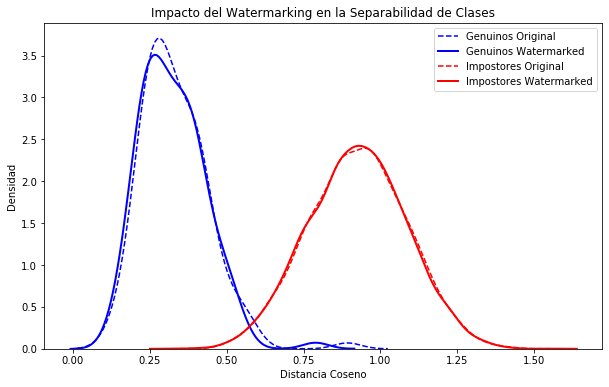

In [151]:
import seaborn as sns

# Graficar las 4 distribuciones para ver el solapamiento
plt.figure(figsize=(10, 6))

# Genuinos
sns.kdeplot(d_gen_oo, label='Genuinos Original', color='blue', ls='--')
sns.kdeplot(d_gen_wm, label='Genuinos Watermarked', color='blue', lw=2)

# Impostores
sns.kdeplot(d_imp_oo, label='Impostores Original', color='red', ls='--')
sns.kdeplot(d_imp_wm, label='Impostores Watermarked', color='red', lw=2)

plt.title("Impacto del Watermarking en la Separabilidad de Clases")
plt.xlabel("Distancia Coseno")
plt.ylabel("Densidad")
plt.legend()
plt.show()

In [152]:
# Calcular la estadística K-S y el p-valor
d_stat, p_value = stats.ks_2samp(cosine_distances_genuine_baseline_online.distance, 
                                 cosine_distances_impostor_baseline_online.distance)

print(f"Estadístico K-S: {d_stat:.4f}")
print(f"P-valor: {p_value:.4e}")

if d_stat > 0.9:
    print("El modelo separa excelentemente bien los grupos.")

Estadístico K-S: 0.9761
P-valor: 4.3299e-15
El modelo separa excelentemente bien los grupos.


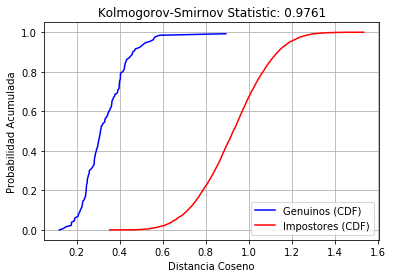

In [153]:
plot_ks(cosine_distances_genuine_baseline_online.distance, 
        cosine_distances_impostor_baseline_online.distance, 
       d_stat)

In [154]:
# Calcular la estadística K-S y el p-valor
d_stat_wm, p_value_wm = stats.ks_2samp(cosine_distances_genuine_watermarked_both_online.distance, 
                                 cosine_distances_impostor_watermarked_both_online.distance)

print(f"Estadístico K-S: {d_stat_wm:.4f}")
print(f"P-valor: {p_value_wm:.4e}")

if d_stat_wm > 0.9:
    print("El modelo separa excelentemente bien los grupos.")

Estadístico K-S: 0.9826
P-valor: 4.3299e-15
El modelo separa excelentemente bien los grupos.


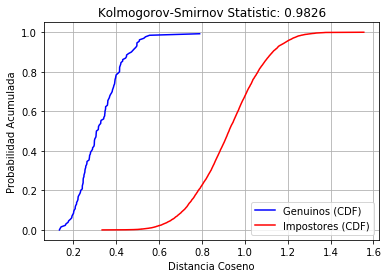

In [155]:
plot_ks(cosine_distances_genuine_watermarked_both_online.distance, 
        cosine_distances_impostor_watermarked_both_online.distance,
       d_stat_wm)

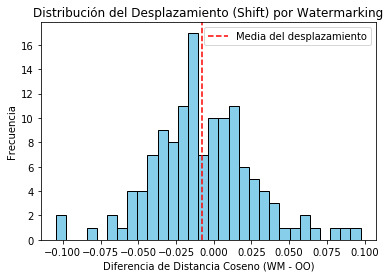

In [156]:
diferencias = cosine_distances_genuine_watermarked_both_online.distance - cosine_distances_genuine_baseline_online.distance

plt.hist(diferencias, bins=30, color='skyblue', edgecolor='black')
plt.axvline(np.mean(diferencias), color='red', linestyle='dashed', label='Media del desplazamiento')
plt.title('Distribución del Desplazamiento (Shift) por Watermarking')
plt.xlabel('Diferencia de Distancia Coseno (WM - OO)')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

In [157]:
from scipy import stats

def cohen_d_scipy(group1, group2):
    # 1. Medias
    m1, m2 = np.mean(group1), np.mean(group2)
    
    # 2. Desviaciones estándar con ddof=1 (Estimación insesgada como en SciPy)
    s1, s2 = np.std(group1, ddof=1), np.std(group2, ddof=1)
    n1, n2 = len(group1), len(group2)
    
    # 3. Pooled standard deviation (s_p de tu fórmula)
    s_p = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
    
    return (m1 - m2) / s_p

def calculate_paired_cohen_d(d_oo, d_wm):
    # d_oo: distancias originales (array)
    # d_wm: distancias con marca de agua (array)
    
    # 1. Medias
    mu_oo = np.mean(d_oo)
    mu_wm = np.mean(d_wm)
    
    # 2. Varianzas (con ddof=1 para ser insesgadas como en SciPy/Estadística)
    var_oo = np.var(d_oo, ddof=1)
    var_wm = np.var(d_wm, ddof=1)
    
    # 3. Pooled Standard Deviation (s_p) simplificada para n1 = n2
    # s_p = sqrt((var1 + var2) / 2)
    s_p = np.sqrt((var_oo + var_wm) / 2)
    
    # 4. d de Cohen según tu imagen
    d_cohen = (mu_wm - mu_oo) / s_p
    
    return d_cohen


In [158]:
# Uso
d_stat_cohen = cohen_d_scipy(cosine_distances_genuine_watermarked_both_online.distance, 
                       cosine_distances_genuine_baseline_online.distance)

d_stat_cohen

-0.06988956115193912

In [159]:
d_cohen = calculate_paired_cohen_d(cosine_distances_genuine_baseline_online.distance, 
                                   cosine_distances_genuine_watermarked_both_online.distance)
d_cohen

-0.06988956115193913

In [160]:
# d_oo: distancias originales
# d_wm: distancias con watermarking
t_stat, p_value = stats.ttest_rel(cosine_distances_genuine_watermarked_both_online.distance, 
                                  cosine_distances_genuine_baseline_online.distance)

print(f"Estadístico T: {t_stat:.4f}")
print(f"P-valor: {p_value:.6f}")

# Interpretación estándar
alpha = 0.05
if p_value < alpha:
    print("El cambio es estadísticamente significativo (p < 0.05).")
else:
    print("El cambio NO es estadísticamente significativo (p > 0.05).")

Estadístico T: -2.5149
P-valor: 0.013135
El cambio es estadísticamente significativo (p < 0.05).


In [161]:
# Diferencia punto a punto
mean_diff = np.mean(diferencias)
sem = stats.sem(diferencias) # Error estándar de la media

# Intervalo de confianza al 95%
ci = stats.t.interval(0.95, len(diferencias)-1, loc=mean_diff, scale=sem)

print(f"Desplazamiento promedio: {mean_diff:.6f}")
print(f"Intervalo de confianza 95%: {ci}")

Desplazamiento promedio: -0.007487
Intervalo de confianza 95%: (-0.01337670970821403, -0.0015968071686668977)


In [162]:
def decidability_index(genuinos, impostores):
    mu_gen = np.mean(genuinos)
    mu_imp = np.mean(impostores)
    var_gen = np.var(genuinos, ddof=1)
    var_imp = np.var(impostores, ddof=1)
    
    # Denominador (combinación de varianzas)
    denom = np.sqrt(0.5 * (var_gen + var_imp))
    
    return np.abs(mu_imp - mu_gen) / denom

# 1. Calcular para el sistema original
d_prime_oo = decidability_index(d_gen_oo, d_imp_oo)

# 2. Calcular para el sistema con marca de agua
d_prime_wm = decidability_index(d_gen_wm, d_imp_wm)

# 3. Ver la pérdida de decidibilidad
loss = (d_prime_oo - d_prime_wm) / d_prime_oo * 100

In [163]:

# Comparar si las varianzas son distintas
stat, p_val_var = stats.levene(d_gen_oo, d_gen_wm)

print(f"P-valor de varianza (Levene): {p_val_var:.6f}")
if p_val_var < 0.05:
    print("¡La varianza ha cambiado significativamente!")
else:
    print("La varianza se mantiene estable.")

P-valor de varianza (Levene): 0.947896
La varianza se mantiene estable.


In [164]:
from scipy.stats import entropy

def calculate_kl_divergence(data_p, data_q, bins=100):
    """
    Calcula la Divergencia KL entre dos muestras.
    P suele ser la original (referencia) y Q la modificada (watermarked).
    """
    # 1. Definir el rango común para que ambas distribuciones sean comparables
    low = min(np.min(data_p), np.min(data_q))
    high = max(np.max(data_p), np.max(data_q))
    
    # 2. Crear histogramas (estimación de la PDF)
    p_hist, _ = np.histogram(data_p, bins=bins, range=(low, high), density=True)
    q_hist, _ = np.histogram(data_q, bins=bins, range=(low, high), density=True)
    
    # 3. Normalizar para que sumen 1 (convertir en probabilidades)
    p = p_hist / np.sum(p_hist)
    q = q_hist / np.sum(q_hist)
    
    # 4. Añadir un valor ínfimo (epsilon) para evitar log(0) o división por cero
    epsilon = 1e-10
    p = p + epsilon
    q = q + epsilon
    
    # 5. Calcular KL Divergence usando scipy
    # entropy(p, q) calcula la KL Divergence D_KL(P || Q)
    kl_div = entropy(p, q)
    
    return kl_div, p, q



In [165]:
var_oo = np.var(d_gen_oo)
var_wm = np.var(d_gen_wm)
ratio = var_wm / var_oo
print(f"La varianza aumentó un: {(ratio-1)*100:.2f}%")

La varianza aumentó un: -7.87%


In [166]:
# Uso con tus datos:
# d_oo: Genuinos Originales
# d_wm: Genuinos Watermarked
kl_val, p, q = calculate_kl_divergence(d_gen_oo, d_gen_wm)

print(f"Divergencia KL: {kl_val:.6f}")

Divergencia KL: 1.491081


In [167]:
from scipy.spatial.distance import jensenshannon

# Usando los histogramas p y q calculados arriba:
js_dist = jensenshannon(p, q)
print(f"Distancia Jensen-Shannon (0 a 1): {js_dist:.6f}")

Distancia Jensen-Shannon (0 a 1): 0.322167


In [168]:
from scipy.stats import wasserstein_distance

# Calcula la distancia real entre las dos distribuciones
w_dist = wasserstein_distance(d_gen_oo, d_gen_wm)

print(f"Distancia de Wasserstein: {w_dist:.6f}")

Distancia de Wasserstein: 0.008821


In [169]:
print('Summary')
print('d cohen:', d_cohen)
print('Estadístico T:', t_stat, 'and P valor', p_value)
print(f"Intervalo de confianza 95%: {ci}")
print(f"Desplazamiento promedio: {mean_diff:.6f}")
print(f"Decidibilidad Original: {d_prime_oo:.4f}")
print(f"Decidibilidad Watermarked: {d_prime_wm:.4f}")
print(f"Pérdida de separabilidad: {loss:.2f}%")
print(f"Estadístico K-S oo: {d_stat:.4f}")
print(f"Estadístico K-S wm: {d_stat_wm:.4f}")


Summary
d cohen: -0.06988956115193913
Estadístico T: -2.5149163810753064 and P valor 0.013134885119409944
Intervalo de confianza 95%: (-0.01337670970821403, -0.0015968071686668977)
Desplazamiento promedio: -0.007487
Decidibilidad Original: 4.3181
Decidibilidad Watermarked: 4.4205
Pérdida de separabilidad: -2.37%
Estadístico K-S oo: 0.9761
Estadístico K-S wm: 0.9826


# Face recognition errors

In [ ]:
def parse_bpp_from_experiment(exp_name: str) -> Optional[int]:
    parts = exp_name.split("_")
    
    if parts[0] == "1" and parts[1] == '1':
        return 1
    elif parts[0] == "1" and parts[1] == '3':
        return 3
    elif parts[0] == "3" and parts[1] == '3' and "stegformer" in exp_name.lower():
        return 3
    elif parts[0] == "3" and parts[1] == '3':
        return 6
    elif parts[0] == "15" and parts[1] == '2':
        return 8
    elif parts[0] == "2" and parts[1] == '8' and "stegformer" in exp_name.lower():
        return 8
    else:
        print(f"[WARN] Could not parse bpp from experiment name: {exp_name}")
        return None


In [ ]:
def read_all_distances_files(path_genuine_pairs_labels, path_impostor_pairs_labels,
                             path_OO_genuine, path_OW_genuine, path_WW_genuine,
                             path_OO_impostor, path_OW_impostor, path_WW_impostor) -> pd.DataFrame:
    
    # Leer todos los archivos y concatenar en un solo DataFrame largo
    dfs = []
    pair_genuine_labels_df = pd.read_excel(path_genuine_pairs_labels)
    pair_impostor_labels_df = pd.read_excel(path_impostor_pairs_labels)

    for path, condition, pair_type in [
        (path_OO_genuine, 'OO', 'genuine'),
        (path_OW_genuine, 'OW', 'genuine'),
        (path_WW_genuine, 'WW', 'genuine'),
        (path_OO_impostor, 'OO', 'impostor'),
        (path_OW_impostor, 'OW', 'impostor'),
        (path_WW_impostor, 'WW', 'impostor'),
    ]:
        df = pd.read_csv(path)
        df['condition'] = condition
        df['pair_type'] = pair_type
        if pair_type == 'genuine':
            df = pd.concat([pair_genuine_labels_df, df], axis=1)
        else:
            df = pd.concat([pair_impostor_labels_df, df], axis=1)
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

In [ ]:
def prepare_distance_dataframe(model_name, test_ds, exp_names_list, recognizer) -> pd.DataFrame:
    all_df_list = []
    for exp_name in exp_names_list:
        bpp = parse_bpp_from_experiment(exp_name)
        for train_ds in ['celeba_hq', 'coco']:
            # paths
            path_OO_genuine = r'C:\Users\JotaR\Documents\Github\WAFIS-ICAOeval\experiments\output\recognition\{}\{}\{}\{}\{}\distances\cosine_genuine_distances_baseline_online.csv'.format(model_name, exp_name, train_ds, test_ds, recognizer)
            path_OW_genuine = r'C:\Users\JotaR\Documents\Github\WAFIS-ICAOeval\experiments\output\recognition\{}\{}\{}\{}\{}\distances\cosine_genuine_distances_watermarked_online.csv'.format(model_name, exp_name, train_ds, test_ds, recognizer)
            path_WW_genuine = r'C:\Users\JotaR\Documents\Github\WAFIS-ICAOeval\experiments\output\recognition\{}\{}\{}\{}\{}\distances\cosine_genuine_distances_watermarked_both_online.csv'.format(model_name, exp_name, train_ds, test_ds, recognizer)
            path_OO_impostor = r'C:\Users\JotaR\Documents\Github\WAFIS-ICAOeval\experiments\output\recognition\{}\{}\{}\{}\{}\distances\cosine_impostor_distances_baseline_online.csv'.format(model_name, exp_name, train_ds, test_ds, recognizer)
            path_OW_impostor = r'C:\Users\JotaR\Documents\Github\WAFIS-ICAOeval\experiments\output\recognition\{}\{}\{}\{}\{}\distances\cosine_impostor_distances_watermarked_online.csv'.format(model_name, exp_name, train_ds, test_ds, recognizer)
            path_WW_impostor = r'C:\Users\JotaR\Documents\Github\WAFIS-ICAOeval\experiments\output\recognition\{}\{}\{}\{}\{}\distances\cosine_impostor_distances_watermarked_both_online.csv'.format(model_name, exp_name, train_ds, test_ds, recognizer)
            path_genuine_pairs_labels = r'C:\Users\JotaR\Documents\Github\WAFIS-ICAOeval\experiments\output\recognition\{}\{}\{}\{}\{}\distances\{}_genuine_pairs.xlsx'.format(model_name, exp_name, train_ds, test_ds, recognizer, test_ds)
            path_impostor_pairs_labels = r'C:\Users\JotaR\Documents\Github\WAFIS-ICAOeval\experiments\output\recognition\{}\{}\{}\{}\{}\distances\{}_impostor_pairs.xlsx'.format(model_name, exp_name, train_ds, test_ds, recognizer, test_ds)

            all_df = read_all_distances_files(path_genuine_pairs_labels, path_impostor_pairs_labels,
                                path_OO_genuine, path_OW_genuine, path_WW_genuine,
                                path_OO_impostor, path_OW_impostor, path_WW_impostor)
            all_df['bpp'] = bpp
            all_df['train_dataset'] = train_ds
            all_df['test_dataset'] = test_ds
            all_df_list.append(all_df)
    all_distances_df = pd.concat(all_df_list, ignore_index=True)

    return all_distances_df

In [ ]:
all_distances_df = prepare_distance_dataframe(model_name='stegaformer', test_ds='CFD', 
                                              exp_names_list=['1_1_255_w16_learn_im','1_3_255_w16_learn_im','3_3_255_w16_learn_im','15_2_255_w16_learn_im'], 
                                              recognizer='facenet')

In [ ]:
all_distances_df.loc[(all_distances_df.bpp==1) 
                     & (all_distances_df.condition=='OO') 
                     & (all_distances_df.train_dataset=='celeba_hq')
                     & (all_distances_df.pair_type=='genuine')].distance.describe()

In [ ]:
def find_label_flips(df: pd.DataFrame, bpp: int, threshold: float, train_ds: str):
    """
    Given a fixed bpp and a distance threshold, identify the pairs (id_a, id_b)
    that change their class (genuine <-> impostor) when going from condition
    OO (baseline) to OW or WW.

    The class is recomputed with the rule:
        distance <= threshold -> 'genuine'
        distance >  threshold -> 'impostor'

    Returns
    -------
    summary : pd.DataFrame
        One row per (id_a, id_b) with the number of changes observed
        across OO->OW and OO->WW transitions, sorted by n_changes desc.
    flips_OO_OW : pd.DataFrame
        Detailed rows where the label changes between OO and OW.
    flips_OO_WW : pd.DataFrame
        Detailed rows where the label changes between OO and WW.
    """
    # 1) Fijar bpp y calcular etiqueta según el umbral
    df_bpp = df[(df["bpp"] == bpp) & (df['train_dataset']==train_ds)].copy()
    df_bpp["label_thr"] = np.where(
        df_bpp["distance"] <= threshold, "genuine", "impostor"
    )

    # 2) Tomar la condición base OO
    base = (
        df_bpp[df_bpp["condition"] == "OO"]
        [["id_a", "id_b", "distance", "label_thr"]]
        .rename(columns={
            "distance": "dist_OO",
            "label_thr": "label_OO",
        })
    )

    def _compute_flips(target_condition: str) -> pd.DataFrame:
        """Merge OO with otra condición (OW o WW) y detectar cambios."""
        other = (
            df_bpp[df_bpp["condition"] == target_condition]
            [["id_a", "id_b", "distance", "label_thr"]]
            .rename(columns={
                "distance": f"dist_{target_condition}",
                "label_thr": f"label_{target_condition}",
            })
        )

        merged = base.merge(other, on=["id_a", "id_b"], how="inner")
        # Filtrar solo donde hay cambio de etiqueta
        flips = merged[merged["label_OO"] != merged[f"label_{target_condition}"]].copy()
        if flips.empty:
            return flips

        # Tipo de cambio y diferencia de distancias (opcional para ordenar)
        flips["change_type"] = (
            flips["label_OO"] + "->" + flips[f"label_{target_condition}"]
        )
        flips["delta_distance"] = (
            flips[f"dist_{target_condition}"] - flips["dist_OO"]
        )

        # Ordenar, por ejemplo, por tipo de cambio y |delta_distance|
        flips = flips.sort_values(
            by=["change_type", "delta_distance"],
            ascending=[True, False],
        )
        return flips

    # 3) Cambios OO->OW y OO->WW
    flips_OO_OW = _compute_flips("OW")
    flips_OO_WW = _compute_flips("WW")

    # 4) Resumen: ¿qué parejas tuvieron más cambios?
    all_flips_list = []
    for cond, df_flips in [("OO->OW", flips_OO_OW), ("OO->WW", flips_OO_WW)]:
        if not df_flips.empty:
            tmp = df_flips[["id_a", "id_b", "change_type"]].copy()
            tmp["transition"] = cond
            all_flips_list.append(tmp)

    if all_flips_list:
        all_flips = pd.concat(all_flips_list, ignore_index=True)
        summary = (
            all_flips.groupby(["id_a", "id_b"])
            .size()
            .reset_index(name="n_changes")
            .sort_values("n_changes", ascending=False)
        )
    else:
        summary = pd.DataFrame(columns=["id_a", "id_b", "n_changes"])

    return summary, flips_OO_OW, flips_OO_WW

In [ ]:
all_distances_df.loc[(all_distances_df.id_a == 'S936982627') & (all_distances_df.id_b == 'S936982627') & (all_distances_df.bpp == 1) ]

In [ ]:
summary, flips_OO_OW, flips_OO_WW = find_label_flips(df=all_distances_df, bpp=1, threshold=0.230, train_ds='celeba_hq')

In [ ]:
flips_OO_OW

In [ ]:
flips_OO_WW

In [ ]:
from PIL import Image, ImageOps


In [ ]:
def compute_bpp(model_name: str, exp_name: str) -> int:
    splits = exp_name.split('_')
    if model_name.lower() == 'stegaformer':
        if splits[0] == '1' and splits[1] == '1':
            bpp = 1
        elif splits[0] == '1' and splits[1] == '3':
            bpp = 3
        elif splits[0] == '3' and splits[1] == '3':
            bpp = 6
        elif splits[0] == '15' and splits[1] == '2':
            bpp = 8
        else:
            raise ValueError(f'Unknown experiment name format: {exp_name}')
    elif model_name.lower() == 'stegformer':
        if splits[0] == '1' and splits[1] == '1':
            bpp = 1
        elif splits[0] == '3' and splits[1] == '3':
            bpp = 3
        elif splits[0] == '3' and splits[1] == '6':
            bpp = 6
        elif splits[0] == '2' and splits[1] == '8':
            bpp = 8
        else:
            raise ValueError(f'Unknown experiment name format: {exp_name}')
    else:
        raise ValueError(f'Unknown model name: {model_name}')
    return bpp


def visualize_flips_condition(
    df: pd.DataFrame,
    exp_name: str,
    dataset: str,
    train_dataset: str,
    model_name: str,
    threshold: float,
    condition: str,   # 'OW' o 'WW'
) -> None:

    assert condition in ["OW", "WW"], "condition debe ser 'OW' o 'WW'"

    bpp = compute_bpp(model_name, exp_name)

    summary, flips_OW, flips_WW = find_label_flips(
        df, bpp=bpp, threshold=threshold, train_ds=train_dataset
    )

    df_flips = flips_OW if condition == "OW" else flips_WW

    if df_flips.empty:
        print(f"No hay cambios de etiqueta para la condición {condition} con esos parámetros.")
        return

    # Seleccionar los 2 casos con mayor |delta_distance|
    df_flips = df_flips.copy()
    df_flips["abs_delta"] = df_flips["delta_distance"].abs()

    gi = df_flips[df_flips["change_type"] == "genuine->impostor"].sort_values("abs_delta", ascending=False)
    ig = df_flips[df_flips["change_type"] == "impostor->genuine"].sort_values("abs_delta", ascending=False)

    selected_rows = []

    if not gi.empty:
        selected_rows.append(gi.iloc[0])
    if not ig.empty:
        selected_rows.append(ig.iloc[0])

    if len(selected_rows) < 2:
        remaining = df_flips.sort_values("abs_delta", ascending=False)
        for _, row in remaining.iterrows():
            already = any(
                (row["id_a"] == r["id_a"]) and
                (row["id_b"] == r["id_b"]) and
                (row["change_type"] == r["change_type"])
                for r in selected_rows
            )
            if not already:
                selected_rows.append(row)
            if len(selected_rows) == 2:
                break

    # Rutas 
    base_output_dir = r'C:\Users\JotaR\Documents\Github\WAFIS-ICAOeval\experiments\output\watermarking\{}\{}\inference\{}\{}'.format(model_name, 
                                                                                                                                     exp_name, train_dataset, dataset)
    original_images_dir = r'C:\Users\JotaR\Documents\Github\WAFIS-ICAOeval\datasets\{}\processed\test'.format(dataset)
    original_templates_dir = r'C:\Users\JotaR\Documents\Github\WAFIS-ICAOeval\datasets\{}\processed\templates'.format(dataset)
    watermarked_images_dir = os.path.join(base_output_dir, 'watermarked_images')
    watermarked_templates_dir = os.path.join(base_output_dir, 'watermarked_templates')

    output_viz_dir = r'C:\Users\JotaR\Documents\Github\WAFIS-ICAOeval\evaluation\visualizations\{}\differences\{}\{}\{}\flips_{}'.format(model_name, 
                                                                                                                                         train_dataset, dataset, bpp, condition)
    os.makedirs(output_viz_dir, exist_ok=True)
    for idx, row in enumerate(selected_rows, start=1):
        id_a = str(row["id_a"])
        id_b = str(row["id_b"])

        if dataset in ["ONOT", "ONOT_set1"]:
            tmpl_path = os.path.join(original_templates_dir, f"{id_a}.png")
            img_filename = [img_name for img_name in os.listdir(original_images_dir) if img_name.startswith(id_b)][0]
            probe_orig_path = os.path.join(original_images_dir, f"{img_filename}")
            tmpl_wm_path = os.path.join(watermarked_templates_dir, f"{id_a}.png")
            probe_wm_path = os.path.join(watermarked_images_dir, f"{img_filename}")
        else:
            tmpl_path = os.path.join(original_templates_dir, f"{id_a}.jpg")
            img_filename = [img_name for img_name in os.listdir(original_images_dir) if img_name.startswith(id_b)][0]
            probe_orig_path = os.path.join(original_images_dir, f"{img_filename.replace('.png', '.jpg')}")
            tmpl_wm_path = os.path.join(watermarked_templates_dir, f"{id_a}.png")
            probe_wm_path = os.path.join(watermarked_images_dir, f"{img_filename}")

        needed = [tmpl_path, probe_orig_path, probe_wm_path]
        if condition == "WW":
            needed.append(tmpl_wm_path)

        print(needed)
        if any(not os.path.exists(p) for p in needed):
            print(f"Saltando par ({id_a}, {id_b}) por falta de archivos de imagen.")
            continue

        # Cargar imágenes
        tmpl_img = Image.open(tmpl_path).convert("RGB")
        probe_orig = Image.open(probe_orig_path).convert("RGB")
        probe_wm = Image.open(probe_wm_path).convert("RGB")
        tmpl_img = ImageOps.fit(tmpl_img, (256, 256))
        probe_orig = ImageOps.fit(probe_orig, (256, 256))
        #probe_wm = ImageOps.fit(probe_wm, (256, 256))

        if condition == "WW":
            tmpl_wm = Image.open(tmpl_wm_path).convert("RGB")
            #tmpl_wm = ImageOps.fit(tmpl_wm, (256, 256))

        # Diferencia probe
        orig_np = np.array(probe_orig).astype(float)
        wm_np = np.array(probe_wm).astype(float)
        abs_diff_p = np.abs(wm_np - orig_np)
        mag_p = abs_diff_p.mean(axis=-1) 
        max_mag_p = mag_p.max() if mag_p.max() > 0 else 1.0
        diff_display_p = 1.0 - (mag_p / max_mag_p)

        if condition == "WW":
            # Diferencia template
            tmpl_np = np.array(tmpl_img).astype(float)
            tmpl_wm_np = np.array(tmpl_wm).astype(float)
            abs_diff_t = np.abs(tmpl_wm_np - tmpl_np)
            mag_t = abs_diff_t.mean(axis=-1) 
            max_mag_t = mag_t.max() if mag_t.max() > 0 else 1.0
            diff_display_t = 1.0 - (mag_t / max_mag_t)

        # Figuras
        if condition == "OW":
            fig, axes = plt.subplots(1, 4, figsize=(12, 4))
            for ax in axes:
                ax.axis("off")

            axes[0].imshow(tmpl_img)
            axes[0].set_title("Original template")

            axes[1].imshow(probe_orig)
            axes[1].set_title("Original probe")

            axes[2].imshow(probe_wm)
            axes[2].set_title("Watermarked probe")

            axes[3].imshow(diff_display_p, cmap="gray", vmin=0.0, vmax=1.0)
            axes[3].set_title("Difference")

        else:  # WW → 6 plots
            fig, axes = plt.subplots(1, 6, figsize=(18, 4))
            for ax in axes:
                ax.axis("off")

            axes[0].imshow(tmpl_img)
            axes[0].set_title("Original template")

            axes[1].imshow(probe_orig)
            axes[1].set_title("Original probe")

            axes[2].imshow(tmpl_wm)
            axes[2].set_title("Watermarked template")

            axes[3].imshow(probe_wm)
            axes[3].set_title("Watermarked probe")

            axes[4].imshow(diff_display_t, cmap="gray", vmin=0.0, vmax=1.0)
            axes[4].set_title("Template difference")

            axes[5].imshow(diff_display_p, cmap="gray", vmin=0.0, vmax=1.0)
            axes[5].set_title("Probe difference")

        plt.subplots_adjust(wspace=0, hspace=0)

        # Texto inferior
        change_desc = row["change_type"].replace("genuine", "Genuine").replace("impostor", "Impostor")
        dist_OO = row["dist_OO"]
        if condition == "OW":
            dist_other = row["dist_OW"]
            label_other = "Original vs Watermarked"
        else:
            dist_other = row["dist_WW"]
            label_other = "Watermarked vs Watermarked"

        fig.supxlabel(
            f"{change_desc} - Original vs Original: {dist_OO:.4f} - {label_other}: {dist_other:.4f}",
            fontsize=14,
            y=0.15
        )
        
        out_name = f"flip_{condition}_{idx}_{id_a}_{id_b}.png"
        save_path = os.path.join(output_viz_dir, out_name)
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
        plt.close(fig)
        print(f"✅ Guardado: {save_path}")

In [ ]:
visualize_flips_condition(
    df=all_distances_df,
    exp_name='1_1_255_w16_learn_im',
    dataset='ONOT',
    train_dataset='celeba_hq',
    model_name='stegaformer',
    threshold=0.230,
    condition='WW'
)